# Feature Engineering

**Цель:** на основе выводов EDA создать новые признаки и собрать
`ColumnTransformer` + `Pipeline`, который будет использоваться и в обучении,
и в продакшене.

**Важно:** все трансформации — внутри Pipeline, чтобы избежать data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import joblib

RANDOM_STATE = 42
RAW_PATH = Path('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df = pd.read_csv(RAW_PATH)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df = df.drop(columns=['customerID'])

print(f"Shape: {df.shape}")
print(f"Пропуски: {df.isna().sum().sum()}")

Shape: (7043, 20)
Пропуски: 11


In [5]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['avg_charges'] = df['TotalCharges'] / (df['tenure'] + 1)

    services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_services'] = (df[services] == 'Yes').sum(axis=1)

    df['is_new_client'] = (df['tenure'] < 6).astype(int)

    df['has_support'] = (
        (df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')
    ).astype(int)

    df['tenure_group'] = pd.cut(
        df['tenure'],
        bins=[-1, 12, 24, 48, 72],
        labels=['0-1y', '1-2y', '2-4y', '4-6y']
    ).astype(str)

    expected = df['tenure'] * df['MonthlyCharges']
    diff_pct = (df['TotalCharges'] - expected).abs() / expected.replace(0, np.nan)
    df['is_charge_anomaly'] = (diff_pct > 0.5).astype(int)

    return df

df = add_features(df)
print(f"После FE: {df.shape}")
df[['tenure', 'MonthlyCharges', 'TotalCharges',
    'avg_charges', 'num_services', 'is_new_client',
    'has_support', 'tenure_group', 'is_charge_anomaly']].head()

После FE: (7043, 26)


,tenure,MonthlyCharges,TotalCharges,avg_charges,num_services,is_new_client,has_support,tenure_group,is_charge_anomaly
0,1,29.85,29.85,14.925000,1,1,0,0-1y,0
1,34,56.95,1889.50,53.985714,2,0,1,2-4y,0
2,2,53.85,108.15,36.050000,2,1,1,0-1y,0
3,45,42.30,1840.75,40.016304,3,0,1,2-4y,0
4,2,70.70,151.65,50.550000,0,1,0,0-1y,0


In [6]:
df[['avg_charges', 'num_services', 'is_new_client',
    'has_support', 'is_charge_anomaly']].describe()

,avg_charges,num_services,is_new_client,has_support,is_charge_anomaly
count,7032.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,59.083067,2.037910,0.194661,0.420843,0.000284
std,30.514438,1.847682,0.395968,0.493730,0.016850
min,9.183333,0.000000,0.000000,0.000000,0.000000
25%,26.225944,0.000000,0.000000,0.000000,0.000000
50%,61.070387,2.000000,0.000000,0.000000,0.000000
75%,84.877538,3.000000,0.000000,1.000000,0.000000
max,118.969863,6.000000,1.000000,1.000000,1.000000


In [7]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"X: {X.shape}, y: {y.shape}")
print(f"Churn rate: {y.mean():.3f}")

X: (7043, 25), y: (7043,)
Churn rate: 0.265


In [8]:
numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'avg_charges', 'num_services',
]

binary_features = ['SeniorCitizen', 'is_new_client', 'has_support', 'is_charge_anomaly']

categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure_group',
]

print(f"Numeric:     {len(numeric_features)}")
print(f"Binary:      {len(binary_features)}")
print(f"Categorical: {len(categorical_features)}")

Numeric:     5
Binary:      4
Categorical: 16


In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features),
    ],
    remainder='drop',
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges',
                                  'avg_charges', 'num_services']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'tenure_group']),
                                ('bin', 'passthrough',
                                 ['SeniorCitizen', 'is_new_client',
                                  'has_support', 'is_charge_anomaly'])])

In [11]:
from pathlib import Path

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.pkl')
print(f"Препроцессор сохранён в {MODELS_DIR / 'preprocessor.pkl'}")

Препроцессор сохранён в ..\models\preprocessor.pkl


C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Никита\AppData\Local\Packages\PythonSoftwareFoundati

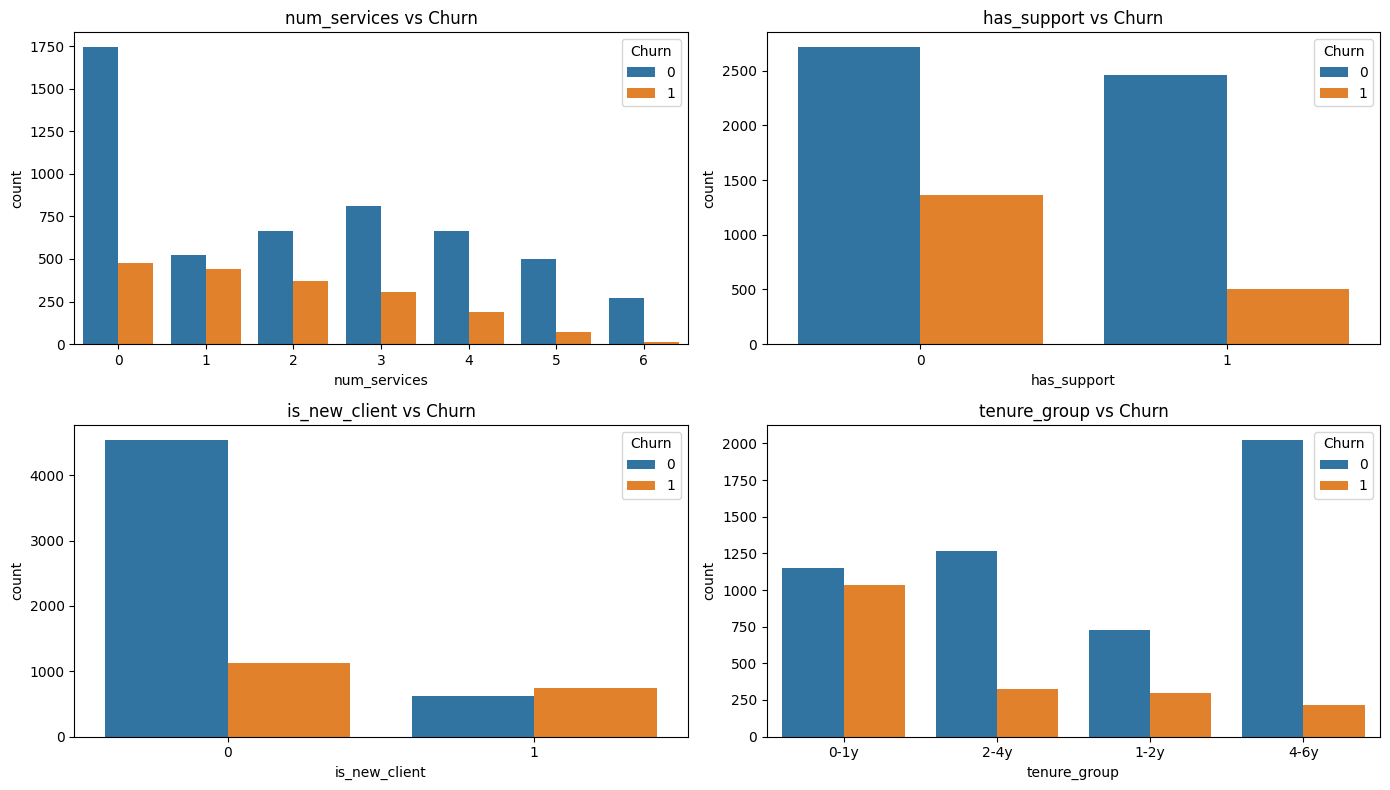

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.countplot(data=df, x='num_services', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('num_services vs Churn')

sns.countplot(data=df, x='has_support', hue='Churn', ax=axes[0, 1])
axes[0, 1].set_title('has_support vs Churn')

sns.countplot(data=df, x='is_new_client', hue='Churn', ax=axes[1, 0])
axes[1, 0].set_title('is_new_client vs Churn')

sns.countplot(data=df, x='tenure_group', hue='Churn', ax=axes[1, 1])
axes[1, 1].set_title('tenure_group vs Churn')

plt.tight_layout()
plt.savefig('../reports/figures/new_features.png', dpi=100, bbox_inches='tight')
plt.show()

## 📌 Выводы по Feature Engineering

### Созданные признаки

| Признак | Формула | Гипотеза |
|---|---|---|
| `avg_charges` | `TotalCharges / (tenure + 1)` | Лечит мультиколлинеарность |
| `num_services` | Сумма `Yes` по 6 услугам | Больше услуг → меньше churn |
| `is_new_client` | `tenure < 6` | Новые клиенты уходят чаще |
| `has_support` | `OnlineSecurity OR TechSupport` | Защита снижает churn |
| `tenure_group` | Бины `[0, 12, 24, 48, 72]` | Нелинейность стажа |
| `is_charge_anomaly` | `diff_pct > 50%` | Нестандартное поведение |

### Препроцессор

- **Numeric:** imputer (median) + StandardScaler.
- **Categorical:** imputer (most_frequent) + OneHotEncoder (`handle_unknown='ignore'`).
- **Binary:** passthrough (уже 0/1).
- **remainder='drop'** — ничего лишнего не просочится.